In [33]:
import os
import pandas as pd
from pathlib import Path
from ucimlrepo import fetch_ucirepo

In [34]:
NOTEBOOK_DIR = Path.cwd()
MODEL_TRAINING_DIR = NOTEBOOK_DIR.parent # Points directly to model_training/
DATA_DIR = MODEL_TRAINING_DIR / "data" / "raw"
CSV_PATH = DATA_DIR / "online_shoppers_intention.csv"

print("Notebook Path:", NOTEBOOK_DIR)
print("Resolved CSV Target:", CSV_PATH)


Notebook Path: c:\Users\l\OneDrive\Desktop\wohoo\AlgoArena\model_training\notebooks
Resolved CSV Target: c:\Users\l\OneDrive\Desktop\wohoo\AlgoArena\model_training\data\raw\online_shoppers_intention.csv


In [35]:
def load_shoppers_data() -> pd.DataFrame:
    """
    Fetch from UCI ML repo or load from local CSV fallback
    """
    if os.path.exists(CSV_PATH):
        print(f"Loading dataset from local CSV: {CSV_PATH}")
        df = pd.read_csv(CSV_PATH)
    else :
        print("Fetching dataset from UCI ML Repository (ID 468)")
        dataset = fetch_ucirepo(id=468)
        x = dataset.data.features
        y = dataset.data.targets
        df = pd.concat([x,y], axis=1)
        df.to_csv(CSV_PATH, index=False)
        print(f"Saved local copy to {CSV_PATH}")
    return df


In [36]:
df = load_shoppers_data()
print("Dataset Shape: ", df.shape)

Loading dataset from local CSV: c:\Users\l\OneDrive\Desktop\wohoo\AlgoArena\model_training\data\raw\online_shoppers_intention.csv
Dataset Shape:  (12330, 18)


In [7]:
print("===DATASET INFO===")
df.info()
print("\n===MISSING VALUES PER COLUMN===")
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0]) if null_counts.sum() > 0 else print("No missing values found.")

===DATASET INFO===
<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType   

In [8]:
print(df.describe().T[['mean', 'std', 'min', 'max', '50%']])

                                mean          std  min           max  \
Administrative              2.315166     3.321784  0.0     27.000000   
Administrative_Duration    80.818611   176.779107  0.0   3398.750000   
Informational               0.503569     1.270156  0.0     24.000000   
Informational_Duration     34.472398   140.749294  0.0   2549.375000   
ProductRelated             31.731468    44.475503  0.0    705.000000   
ProductRelated_Duration  1194.746220  1913.669288  0.0  63973.522230   
BounceRates                 0.022191     0.048488  0.0      0.200000   
ExitRates                   0.043073     0.048597  0.0      0.200000   
PageValues                  5.889258    18.568437  0.0    361.763742   
SpecialDay                  0.061427     0.198917  0.0      1.000000   
OperatingSystems            2.124006     0.911325  1.0      8.000000   
Browser                     2.357097     1.717277  1.0     13.000000   
Region                      3.147364     2.401591  1.0      9.00

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

False: No Purchase: 10422 (84.53%)
True: Purchase: 1908 (15.47%)


C:\Users\l\AppData\Local\Temp\ipykernel_25060\1432324647.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="Revenue", palette=['#e74c3c', '#2ecc71'])


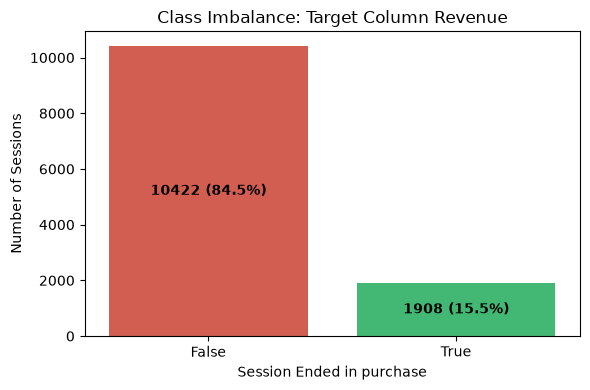

In [12]:
counts = df["Revenue"].value_counts()
proportions = df['Revenue'].value_counts(normalize=True) * 100
print(f"False: No Purchase: {counts[False]} ({proportions[False]:.2f}%)")
print(f"True: Purchase: {counts[True]} ({proportions[True]:.2f}%)")

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="Revenue", palette=['#e74c3c', '#2ecc71'])
plt.title("Class Imbalance: Target Column Revenue")
plt.xlabel("Session Ended in purchase")
plt.ylabel("Number of Sessions")
for p in ax.patches: 
    ax.annotate(f"{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)",
                (p.get_x() + p.get_width() / 2., p.get_height() / 2), 
                ha='center', va='center', color='black', fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
num_cols = [
    'Administrative', 'Administrative_Duration', 'Informational', 
    'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay'
]
cat_cols = ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']

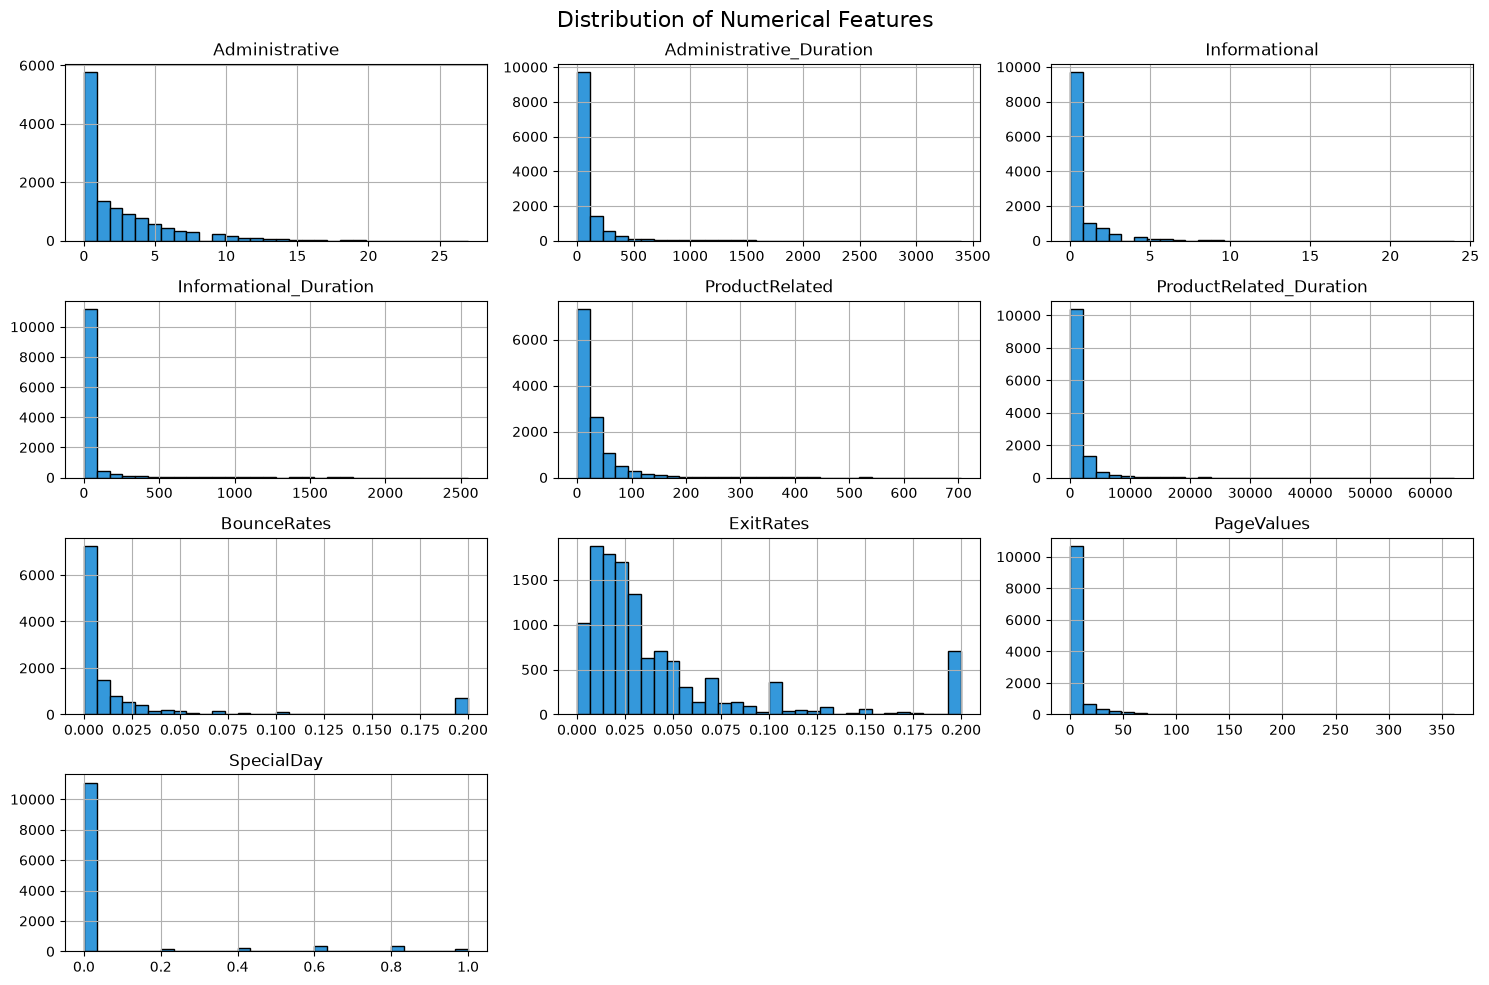

In [14]:
df[num_cols].hist(bins=30, figsize=(15, 10), color='#3498db', edgecolor='black')
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

In [15]:
for col in cat_cols:
    print(f"Categorical Feature: {col} unique values count: {df[col].unique()} -> Values: {df[col].unique()}")
    

Categorical Feature: Month unique values count: <ArrowStringArray>
['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep', 'Dec']
Length: 10, dtype: str -> Values: <ArrowStringArray>
['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep', 'Dec']
Length: 10, dtype: str
Categorical Feature: OperatingSystems unique values count: [1 2 4 3 7 6 8 5] -> Values: [1 2 4 3 7 6 8 5]
Categorical Feature: Browser unique values count: [ 1  2  3  4  5  6  7 10  8  9 12 13 11] -> Values: [ 1  2  3  4  5  6  7 10  8  9 12 13 11]
Categorical Feature: Region unique values count: [1 9 2 3 4 5 6 7 8] -> Values: [1 9 2 3 4 5 6 7 8]
Categorical Feature: TrafficType unique values count: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 18 19 16 17 20] -> Values: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 18 19 16 17 20]
Categorical Feature: VisitorType unique values count: <ArrowStringArray>
['Returning_Visitor', 'New_Visitor', 'Other']
Length: 3, dtype: str -> Values: <ArrowStringArray>
['Re

C:\Users\l\AppData\Local\Temp\ipykernel_25060\1478987315.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Revenue', y='PageValues', data=df, palette=['#e74c3c', '#2ecc71'])
C:\Users\l\AppData\Local\Temp\ipykernel_25060\1478987315.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Month', y='Revenue', data=df, order=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], palette='viridis', ci=None)
C:\Users\l\AppData\Local\Temp\ipykernel_25060\1478987315.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='Revenue', data=df, order=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'Ju

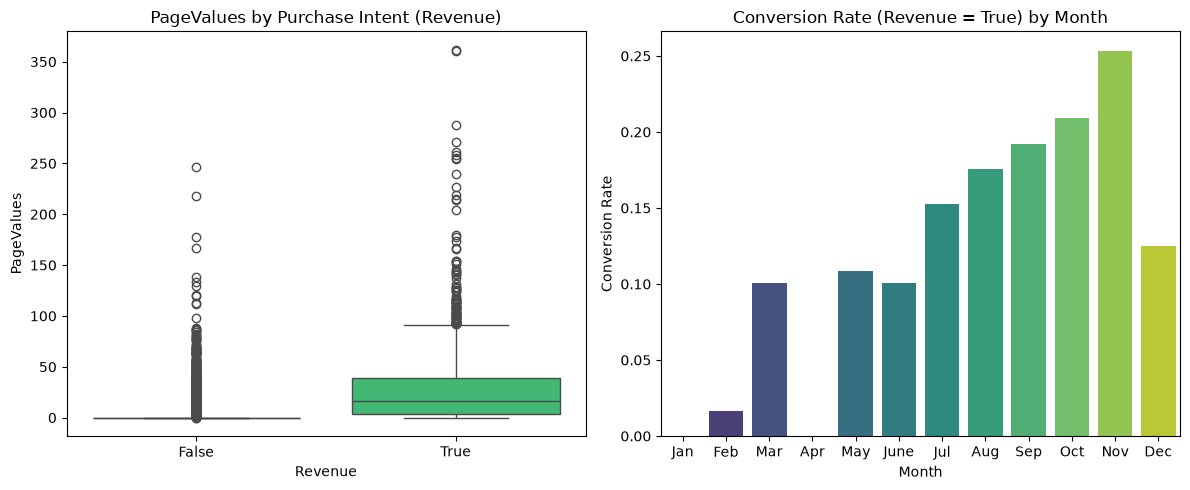

In [16]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='Revenue', y='PageValues', data=df, palette=['#e74c3c', '#2ecc71'])
plt.title("PageValues by Purchase Intent (Revenue)")
plt.subplot(1,2,2)
sns.barplot(x='Month', y='Revenue', data=df, order=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], palette='viridis', ci=None)
plt.title("Conversion Rate (Revenue = True) by Month")
plt.ylabel("Conversion Rate")
plt.tight_layout()
plt.show()

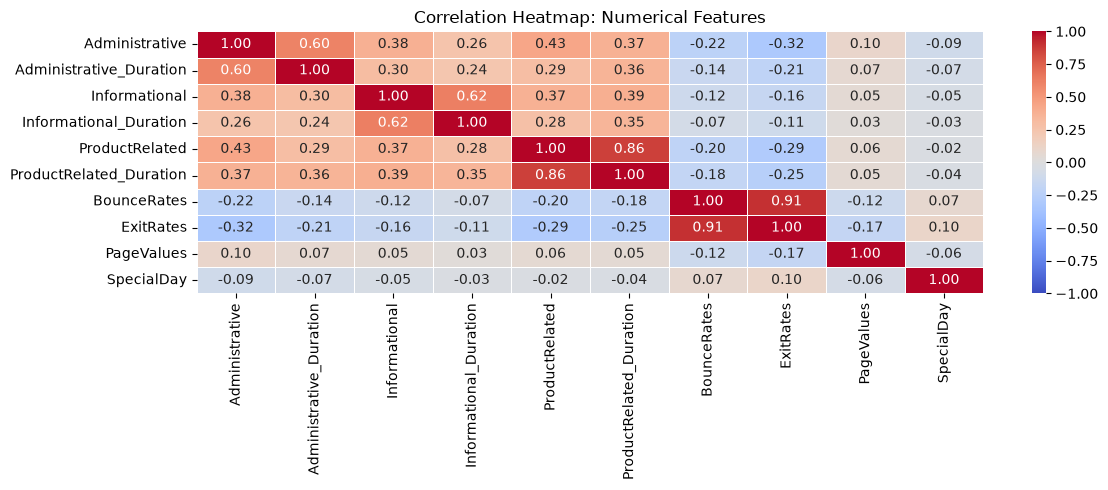

In [17]:
plt.figure(figsize=(12, 5))
corr_matrix = df[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Heatmap: Numerical Features")
plt.tight_layout()
plt.show()

In [18]:
print("===HIGH MULTICOLLINEARITY PAIRS (>0.70)===")
for i in range(len(num_cols)):
    for j in range(i+1, len(num_cols)):
        if abs(corr_matrix.iloc[i, j]) > 0.70:
            print(f"{num_cols[i]} and {num_cols[j]}: Correlation = {corr_matrix.iloc[i, j]:.2f}")

===HIGH MULTICOLLINEARITY PAIRS (>0.70)===
ProductRelated and ProductRelated_Duration: Correlation = 0.86
BounceRates and ExitRates: Correlation = 0.91


In [19]:
from sklearn.preprocessing import OneHotEncoder


In [20]:
def create_encoder(df: pd.DataFrame, cat_cols: list) -> OneHotEncoder:
    """
    Instantiate and fit a OneHotEncoder on the categorical data columns.
    """
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    encoder.fit(df[cat_cols])
    return encoder

cat_cols = ['Month', 'VisitorType']
df['Weekend'] = df['Weekend'].astype(int) #Boolean to 0/1
df['Revenue'] = df['Revenue'].astype(int) #Boolean to Target 0/1

encoder = create_encoder(df, cat_cols)
encoded_cats = encoder.transform(df[cat_cols])
encoded_feature_names = encoder.get_feature_names_out(cat_cols)
df_encoded = pd.DataFrame(encoded_cats, columns=encoded_feature_names, index=df.index)
print(f"Encoded Categorical Columns Count: {len(encoded_feature_names)}")
print(f"Categories sample names:", list(encoded_feature_names[:5]))

Encoded Categorical Columns Count: 13
Categories sample names: ['Month_Aug', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June']


In [22]:
from sklearn.model_selection import train_test_split

In [26]:
num_cols = [
    'Administrative', 'Administrative_Duration', 'Informational', 
    'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
    'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend'
]

x = pd.concat([df[num_cols], df_encoded], axis=1)
y = df['Revenue']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {x_train.shape}, y_train conversion rate: {y_train.mean():.4f}")
print(f"X_test shape:  {x_test.shape}, y_test conversion rate:  {y_test.mean():.4f}")

X_train shape: (9864, 28), y_train conversion rate: 0.1547
X_test shape:  (2466, 28), y_test conversion rate:  0.1549


In [28]:
from sklearn.preprocessing import StandardScaler
import numpy as np

In [29]:
scale_cols = [
    'Administrative', 'Administrative_Duration', 'Informational', 
    'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay'
]

scaler = StandardScaler()

x_train_scaled_num = scaler.fit_transform(x_train[scale_cols])
x_test_scaled_num = scaler.transform(x_test[scale_cols])

x_train_processed = x_train.copy()
x_test_processed = x_test.copy()

x_train_processed[scale_cols] = x_train_scaled_num
x_test_processed[scale_cols] = x_test_scaled_num

print("Scaled Numerical Means (Training:)", np.round(x_train_processed[scale_cols].mean().values, 2))
print("Scaled Numerical Stds (Training):", np.round(x_train_processed[scale_cols].std().values, 2))

Scaled Numerical Means (Training:) [-0. -0. -0.  0.  0.  0.  0.  0. -0. -0.]
Scaled Numerical Stds (Training): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [30]:
import joblib

In [31]:
ARTIFACTS_DIR = os.path.join("model_training", "artifacts")
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

scaler_path = os.path.join(ARTIFACTS_DIR, "scaler.pkl")
encoder_path = os.path.join(ARTIFACTS_DIR, "encoder.pkl")

joblib.dump(scaler, scaler_path)
joblib.dump(encoder, encoder_path)

print(f"Successfully saved scaler to {scaler_path}")
print(f"Successfully saved encoder to {encoder_path}")

loaded_scaler = joblib.load(scaler_path)
loaded_encoder = joblib.load(encoder_path)
print(f"Transformers serialisation test verified successfully.")

Successfully saved scaler to model_training\artifacts\scaler.pkl
Successfully saved encoder to model_training\artifacts\encoder.pkl
Transformers serialisation test verified successfully.
